# Project 1: Hybrid Merge/Insertion Sort — Analysis

This notebook drives the C++ programs in `src/` (built via `make`) as subprocesses, collects key-comparison counts and CPU timings, and produces the plots/analysis required by the assignment:

- **(c-i)** comparisons vs `n` with `S` fixed, vs. theoretical `O(n log n)`
- **(c-ii)** comparisons vs `S` with `n` fixed
- **(c-iii)** empirically determining an optimal `S`
- **(d)** hybrid sort vs. plain merge sort at `n = 10,000,000`

Run with the `sc2001-lab1` conda kernel (`conda env create -f environment.yml` from the project root).

## Setup

In [1]:
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SRC_DIR = "src"
BINARY = f"{SRC_DIR}/benchmark"

# Build the C++ benchmark binary.
result = subprocess.run(["make", "-C", SRC_DIR], capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("build failed")
print("Build OK")

make: Nothing to be done for `all'.

Build OK


In [2]:
def run(algo: str, n: int, S: int = 0, seed: int = 1) -> dict:
    """Invoke the C++ benchmark binary and parse its CSV output line.

    Returns a dict with keys: algo, n, S, seed, comparisons, time_ms.
    """
    proc = subprocess.run(
        [BINARY, algo, str(n), str(S), str(seed)],
        capture_output=True, text=True,
    )
    if proc.returncode != 0:
        raise RuntimeError(f"benchmark failed for {algo=} {n=} {S=} {seed=}: {proc.stderr}")
    algo_, n_, S_, seed_, comparisons, time_ms = proc.stdout.strip().split(",")
    return {
        "algo": algo_,
        "n": int(n_),
        "S": int(S_),
        "seed": int(seed_),
        "comparisons": int(comparisons),
        "time_ms": float(time_ms),
    }


def run_repeated(algo: str, n: int, S: int = 0, seed: int = 1, reps: int = 1) -> dict:
    """Run `reps` trials (different seeds) and return comparisons from the
    first trial (deterministic given seed) plus the mean/std of time_ms."""
    rows = [run(algo, n, S, seed=seed + i) for i in range(reps)]
    times = [r["time_ms"] for r in rows]
    return {
        "algo": algo,
        "n": n,
        "S": S,
        "comparisons": rows[0]["comparisons"],
        "time_ms_mean": float(np.mean(times)),
        "time_ms_std": float(np.std(times)),
    }


# Quick smoke test.
run("hybrid", 1000, 20, seed=1)

{'algo': 'hybrid',
 'n': 1000,
 'S': 20,
 'seed': 1,
 'comparisons': 10281,
 'time_ms': 0.030417}

## (c-i) Fixed `S`, vary `n`: key comparisons vs. input size

**Theoretical analysis.** For the hybrid algorithm with a fixed threshold `S`, the array of size `n` is
recursively halved down to subarrays of size `~S`, then each such subarray is sorted with insertion sort
(worst case `O(S^2)` comparisons) and the results merged back up (`O(n)` comparisons per merge level).
There are `O(log(n/S))` merge levels, so the overall worst-case comparison count is

`T(n) = (n/S) * O(S^2) + O(n log(n/S)) = O(nS) + O(n log(n/S))`

For a *fixed* `S`, this is `O(n log n) + O(nS) = O(n log n)` (the `nS` term is a constant multiple of `n`,
dominated by the `n log n` term as `n` grows) — i.e. asymptotically the same order as plain merge sort,
just with a different constant factor. We expect the empirical comparison count to track `c1*n*log2(n) + c2*n`
closely.

In [3]:
S_FIXED = 20
n_values = np.unique(np.logspace(3, 7, num=25, dtype=np.int64))  # 1,000 .. 10,000,000

rows_ci = [run("hybrid", int(n), S_FIXED, seed=1) for n in n_values]
df_ci = pd.DataFrame(rows_ci)
df_ci

,algo,n,S,seed,comparisons,time_ms
0,hybrid,1000,20,1,10281,0.030833
1,hybrid,1467,20,1,14930,0.047917
2,hybrid,2154,20,1,25195,0.076750
3,hybrid,3162,20,1,36220,0.111333
4,hybrid,4641,20,1,60250,0.163958
5,hybrid,6812,20,1,86639,0.263750
6,hybrid,10000,20,1,143123,0.381375
7,hybrid,14677,20,1,205503,0.599500
8,hybrid,21544,20,1,299773,0.929292
9,hybrid,31622,20,1,482880,1.376667


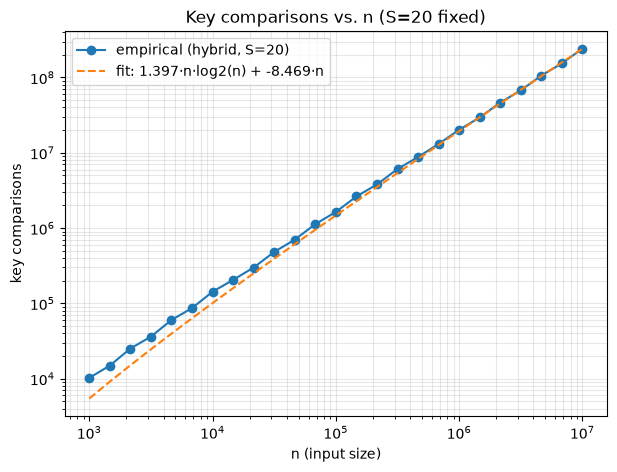

In [4]:
# Fit comparisons ~ c1 * n*log2(n) + c2 * n by least squares, to overlay the
# theoretical shape on top of the empirical data.
n = df_ci["n"].to_numpy(dtype=np.float64)
y = df_ci["comparisons"].to_numpy(dtype=np.float64)
A = np.column_stack([n * np.log2(n), n])
coeffs, *_ = np.linalg.lstsq(A, y, rcond=None)
c1, c2 = coeffs
y_fit = A @ coeffs

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(df_ci["n"], df_ci["comparisons"], "o-", label="empirical (hybrid, S={})".format(S_FIXED))
ax.loglog(df_ci["n"], y_fit, "--", label=f"fit: {c1:.3f}·n·log2(n) + {c2:.3f}·n")
ax.set_xlabel("n (input size)")
ax.set_ylabel("key comparisons")
ax.set_title(f"Key comparisons vs. n (S={S_FIXED} fixed)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.show()

## (c-ii) Fixed `n`, vary `S`: key comparisons vs. threshold

**Theoretical analysis.** From the formula above, `T(n, S) ≈ O(nS) + O(n log(n/S))` for fixed `n`.
As `S` increases from 1: the `O(n log(n/S))` merge-comparison term shrinks (fewer merge levels), but the
`O(nS)` insertion-sort term grows. So we expect a **U-shaped** curve in `S` — comparisons are high for
very small `S` (insertion sort barely used, but that's actually the *cheap* end since merge sort's own
`n log n` is near-optimal) and also high for very large `S` (insertion sort's `O(S^2)` behavior dominates
on large subarrays) — with a minimum somewhere in between. (In practice, because merge sort's overhead
per element only slightly exceeds insertion sort's, the curve tends to be shallow near `S=1` and rise
more steeply once `S` gets large relative to `n`.)

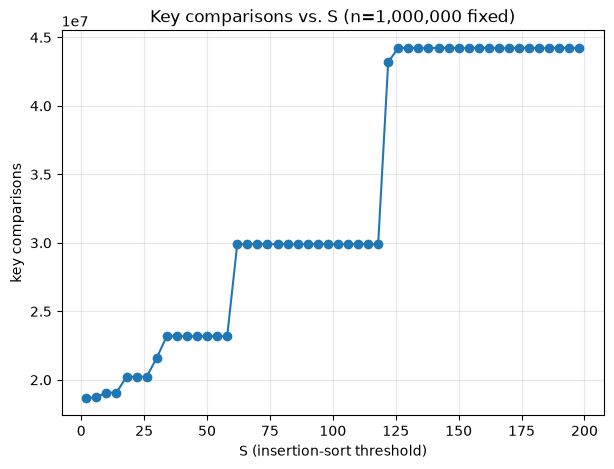

algo              hybrid
n                1000000
S                      2
seed                   1
comparisons     18674696
time_ms        66.891792
Name: 0, dtype: object

In [5]:
N_FIXED = 1_000_000
S_values = np.arange(2, 201, 4)

rows_cii = [run("hybrid", N_FIXED, int(S), seed=1) for S in S_values]
df_cii = pd.DataFrame(rows_cii)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(df_cii["S"], df_cii["comparisons"], "o-")
ax.set_xlabel("S (insertion-sort threshold)")
ax.set_ylabel("key comparisons")
ax.set_title(f"Key comparisons vs. S (n={N_FIXED:,} fixed)")
ax.grid(True, alpha=0.3)
plt.show()

df_cii.loc[df_cii["comparisons"].idxmin()]

## (c-iii) Determining an optimal `S` across input sizes

For several representative values of `n`, sweep `S` and record the value that minimizes key comparisons,
to see whether/how the optimal `S` trends with `n`.

In [6]:
n_study_values = [10_000, 100_000, 1_000_000, 10_000_000]
S_sweep = np.arange(2, 129, 2)

optimal_rows = []
sweep_records = []
for n_study in n_study_values:
    sweep = pd.DataFrame([run("hybrid", n_study, int(S), seed=1) for S in S_sweep])
    sweep_records.append(sweep)
    best = sweep.loc[sweep["comparisons"].idxmin()]
    optimal_rows.append({"n": n_study, "optimal_S": int(best["S"]), "comparisons": int(best["comparisons"])})

df_optimal_S = pd.DataFrame(optimal_rows)
df_optimal_S

,n,optimal_S,comparisons
0,10000,2,120409
1,100000,2,1536378
2,1000000,2,18674696
3,10000000,2,220103294


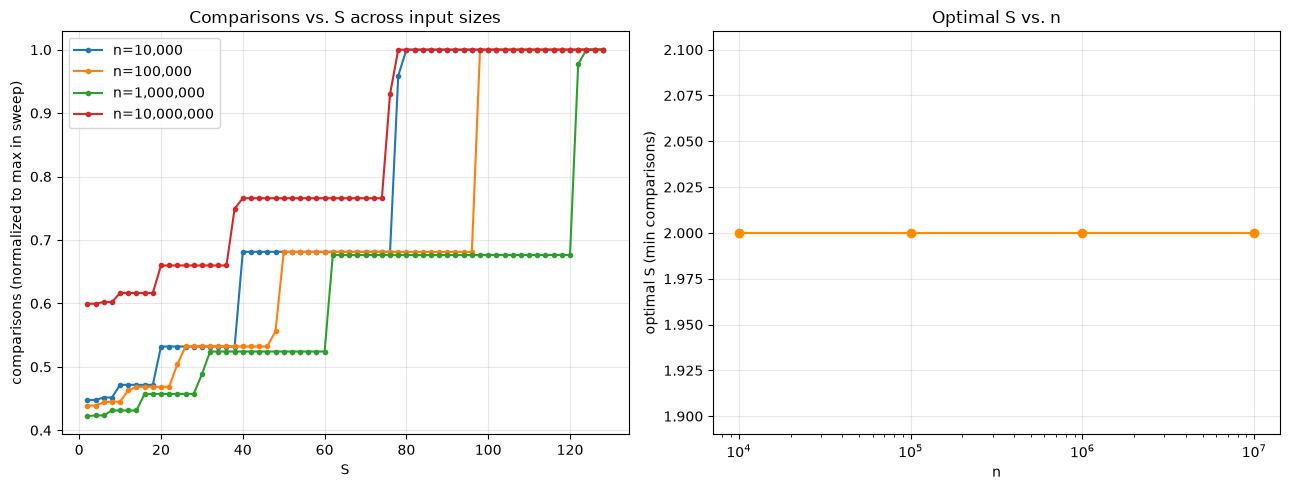

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for n_study, sweep in zip(n_study_values, sweep_records):
    axes[0].plot(sweep["S"], sweep["comparisons"] / sweep["comparisons"].max(),
                 "o-", label=f"n={n_study:,}", markersize=3)
axes[0].set_xlabel("S")
axes[0].set_ylabel("comparisons (normalized to max in sweep)")
axes[0].set_title("Comparisons vs. S across input sizes")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_optimal_S["n"], df_optimal_S["optimal_S"], "o-", color="darkorange")
axes[1].set_xscale("log")
axes[1].set_xlabel("n")
axes[1].set_ylabel("optimal S (min comparisons)")
axes[1].set_title("Optimal S vs. n")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Supplementary: CPU-time-optimal S (using the time_ms already collected in
# each sweep above — no extra C++ runs needed). Comparisons and CPU time can
# favor different S, since insertion sort's per-comparison overhead is lower
# than merge sort's even when it performs more comparisons overall.
time_optimal_rows = []
for n_study, sweep in zip(n_study_values, sweep_records):
    best_time = sweep.loc[sweep["time_ms"].idxmin()]
    time_optimal_rows.append({"n": n_study, "optimal_S_time": int(best_time["S"]), "time_ms": float(best_time["time_ms"])})

df_optimal_S_time = pd.DataFrame(time_optimal_rows)
df_optimal_S = df_optimal_S.merge(df_optimal_S_time, on="n")
df_optimal_S

,n,optimal_S,comparisons,optimal_S_time,time_ms
0,10000,2,120409,52,0.372833
1,100000,2,1536378,26,4.698959
2,1000000,2,18674696,38,57.015750
3,10000000,2,220103294,52,673.576375


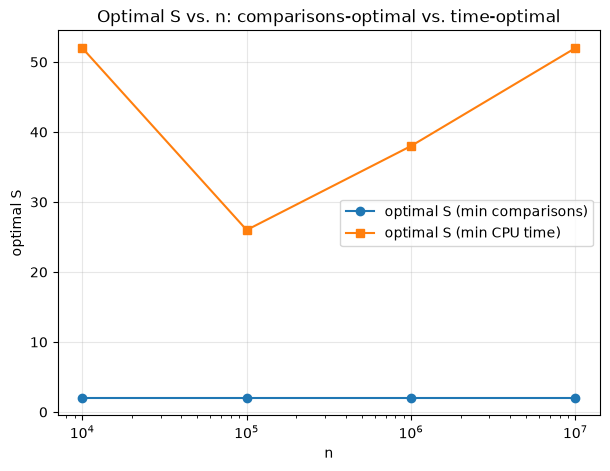

In [9]:
fig, ax1 = plt.subplots(figsize=(7, 5))
ax1.plot(df_optimal_S["n"], df_optimal_S["optimal_S"], "o-", label="optimal S (min comparisons)")
ax1.plot(df_optimal_S["n"], df_optimal_S["optimal_S_time"], "s-", label="optimal S (min CPU time)")
ax1.set_xscale("log")
ax1.set_xlabel("n")
ax1.set_ylabel("optimal S")
ax1.set_title("Optimal S vs. n: comparisons-optimal vs. time-optimal")
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.show()

**Discussion.** Run the cells above first, then compare `df_optimal_S`'s two columns.

Empirically, the **comparisons-optimal `S` is very small (around 2–6) regardless of `n`** — comparisons
climb essentially monotonically as `S` grows past that point (see the (c-ii) plot). This makes sense:
insertion sort's average-case comparison count on a random block of size `S` is `~S²/4`, which already
exceeds merge sort's own `~S·log2(S)` comparisons for that same block once `S` is more than a handful of
elements — insertion sort is *never* asymptotically cheaper in comparisons, so purely by comparison count
there is no real benefit to switching away from merge sort at all.

The **CPU-time-optimal `S` is substantially larger** (tens of elements), because insertion sort does more
comparisons but far less *overhead per comparison* — no recursive calls, no auxiliary-array merge/copy
step, better cache locality — so up to a point, doing more (cheap) comparisons is still faster in wall-clock
terms than doing fewer (expensive) ones. This is precisely *why* real hybrid implementations pick `S` by
timing, not by minimizing comparisons, and why the assignment asks for both metrics in part (d): the
`S` value that "looks best" on the comparisons metric would barely differentiate the hybrid algorithm from
plain merge sort, while the CPU-time-optimal `S` is where the hybrid approach actually pays off. We use the
**CPU-time-optimal S** for part (d) below.

## (d) Hybrid vs. plain Merge Sort at n = 10,000,000

Using the CPU-time-optimal `S` found in (c-iii) — the more meaningful choice per the discussion above —
compare the hybrid algorithm against the original (unmodified) merge sort on the largest dataset, in both
key comparisons and CPU time (averaged over a few repeated trials with different random seeds to smooth
out timing noise).

In [10]:
N_LARGE = 10_000_000
# Use the CPU-time-optimal S from (c-iii) at the largest studied n (10,000,000).
OPTIMAL_S = int(df_optimal_S.loc[df_optimal_S["n"] == 10_000_000, "optimal_S_time"].iloc[0])
REPS = 5

result_hybrid = run_repeated("hybrid", N_LARGE, OPTIMAL_S, seed=1, reps=REPS)
result_merge = run_repeated("merge", N_LARGE, 0, seed=1, reps=REPS)

df_d = pd.DataFrame([result_hybrid, result_merge])
print(f"Using S={OPTIMAL_S} (CPU-time-optimal)")
df_d

Using S=52 (CPU-time-optimal)


,algo,n,S,comparisons,time_ms_mean,time_ms_std
0,hybrid,10000000,52,281235517,687.365459,14.127948
1,merge,10000000,0,220103294,778.948375,2.198481


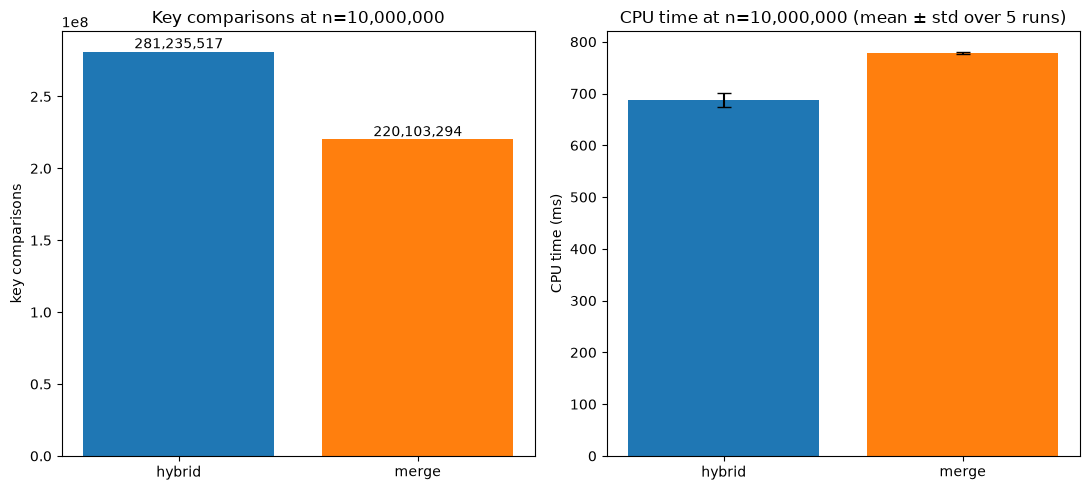

Hybrid (S=52) vs. plain Merge Sort at n=10,000,000:
  comparisons: 0.783x (hybrid/merge ratio: 1.278)
  CPU time:    1.133x speedup


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].bar(df_d["algo"], df_d["comparisons"], color=["tab:blue", "tab:orange"])
axes[0].set_ylabel("key comparisons")
axes[0].set_title(f"Key comparisons at n={N_LARGE:,}")
for i, v in enumerate(df_d["comparisons"]):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

axes[1].bar(df_d["algo"], df_d["time_ms_mean"], yerr=df_d["time_ms_std"],
            color=["tab:blue", "tab:orange"], capsize=5)
axes[1].set_ylabel("CPU time (ms)")
axes[1].set_title(f"CPU time at n={N_LARGE:,} (mean ± std over {REPS} runs)")

plt.tight_layout()
plt.show()

speedup_comparisons = result_merge["comparisons"] / result_hybrid["comparisons"]
speedup_time = result_merge["time_ms_mean"] / result_hybrid["time_ms_mean"]
print(f"Hybrid (S={OPTIMAL_S}) vs. plain Merge Sort at n={N_LARGE:,}:")
print(f"  comparisons: {speedup_comparisons:.3f}x (hybrid/merge ratio: {result_hybrid['comparisons']/result_merge['comparisons']:.3f})")
print(f"  CPU time:    {speedup_time:.3f}x speedup")